In [2]:
import pandas as pd
train_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Train/Trainset_dataset1.xlsx"
test_yield_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/refs/heads/main/Datasets/Test/Testset_dataset1%20(1).csv"
test_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Test/Testset_feature_dataset1.xlsx"

df_train = pd.read_excel(train_url)
df_test = pd.read_excel(test_url)
df_test_feature = pd.read_csv(test_yield_url)
df_train.info()
#df_train.head()
df_test.info()
df_test_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Ash(wt%)                   747 non-null    float64
 1   FixedCarbon(wt%)           747 non-null    float64
 2   Volatiles(wt%)             747 non-null    float64
 3   C(wt%)                     845 non-null    float64
 4   H(wt%)                     835 non-null    float64
 5   O(wt%)                     835 non-null    float64
 6   N(wt%)                     805 non-null    float64
 7   H/C                        835 non-null    float64
 8   Cellulose(wt%)             669 non-null    float64
 9   Hemicellulose(wt%)         483 non-null    float64
 10  Lignin(wt%)                510 non-null    float64
 11  T(^C)                      845 non-null    int64  
 12  HeatingRate(^C/min)        845 non-null    int64  
 13  ParticleSize(mm)           845 non-null    float64

Understanding the data

In [3]:
df_train.shape #how big is the data?
df_train.describe()# datatype of each column




,Ash(wt%),FixedCarbon(wt%),Volatiles(wt%),C(wt%),H(wt%),O(wt%),N(wt%),H/C,Cellulose(wt%),Hemicellulose(wt%),Lignin(wt%),T(^C),HeatingRate(^C/min),ParticleSize(mm),FlowRate-Nitrogen(ml/min),yield(wt%)
count,747.000000,747.000000,747.000000,845.000000,835.000000,835.000000,805.000000,835.000000,669.000000,483.000000,510.000000,845.000000,845.000000,845.000000,845.000000,845.000000
mean,5.623498,16.034171,78.342330,49.267011,6.482051,40.598446,2.933221,0.121796,34.156218,27.509151,22.667353,514.674556,65.073373,0.812234,125.177515,40.478817
std,3.778697,8.540413,9.971436,6.705218,1.155756,8.613152,2.551525,0.041311,11.559224,10.709667,11.559443,90.715530,112.020190,0.526874,242.063168,9.902880
min,0.278552,0.107181,10.855927,19.490000,2.410000,10.490000,0.170000,0.100000,5.750000,3.400000,0.800000,300.000000,5.000000,0.100000,0.000000,11.000000
25%,2.332980,11.981198,75.774742,44.820000,5.890000,34.190000,0.920000,0.100000,27.200000,19.400000,15.000000,450.000000,7.000000,0.450000,0.000000,33.000000
50%,5.245536,14.880575,78.747204,47.400000,6.230000,41.630000,2.050000,0.100000,32.060000,25.520000,26.110000,500.000000,20.000000,0.650000,100.000000,40.300000
75%,7.286460,17.114094,83.102511,52.900000,6.735700,48.280000,4.400000,0.100000,43.000000,36.550000,30.100000,550.000000,50.000000,1.000000,100.000000,47.800000
max,40.084388,78.545821,95.984215,79.770000,10.590000,54.120000,9.290000,0.200000,60.270000,51.340000,50.400000,900.000000,800.000000,3.200000,2000.000000,77.200000


Find out Total Missing values of each column

In [3]:
print(df_train.isnull().sum())
print()
print(df_test.isnull().sum())

Ash(wt%)                      98
FixedCarbon(wt%)              98
Volatiles(wt%)                98
C(wt%)                         0
H(wt%)                        10
O(wt%)                        10
N(wt%)                        40
H/C                           10
Cellulose(wt%)               176
Hemicellulose(wt%)           362
Lignin(wt%)                  335
T(^C)                          0
HeatingRate(^C/min)            0
ParticleSize(mm)               0
FlowRate-Nitrogen(ml/min)      0
yield(wt%)                     0
dtype: int64

Ash(wt%)                     28
FixedCarbon(wt%)             28
Volatiles(wt%)               28
C(wt%)                        0
H(wt%)                        5
O(wt%)                        5
N(wt%)                       11
H/C                           5
Cellulose(wt%)               49
Hemicellulose(wt%)           83
Lignin(wt%)                  77
T(^C)                         0
HeatingRate(^C/min)           0
ParticleSize(mm)              0
FlowRate-N

In [4]:
print(df_train.duplicated().sum())
#df_train[df_train.duplicated()] # Print the duplicates
df_train.drop_duplicates(inplace=True)
print(df_train.duplicated().sum())

37
0


In [5]:
"""from ydata_profiling import ProfileReport
prof=ProfileReport(df_train)
prof.to_file(output_file='output_train.html')
prof=ProfileReport(df_test)
prof.to_file(output_file='output_test.html')
prof=ProfileReport(df_test_feature)
prof.to_file(output_file='output_test_feature.html')"""

"from ydata_profiling import ProfileReport\nprof=ProfileReport(df_train)\nprof.to_file(output_file='output_train.html')\nprof=ProfileReport(df_test)\nprof.to_file(output_file='output_test.html')\nprof=ProfileReport(df_test_feature)\nprof.to_file(output_file='output_test_feature.html')"

EDA

Univariant Analysis


(array([  5.,  36., 105., 185., 205., 144.,  91.,  35.,   1.,   1.]),
 array([11.  , 17.62, 24.24, 30.86, 37.48, 44.1 , 50.72, 57.34, 63.96,
        70.58, 77.2 ]),
 <BarContainer object of 10 artists>)

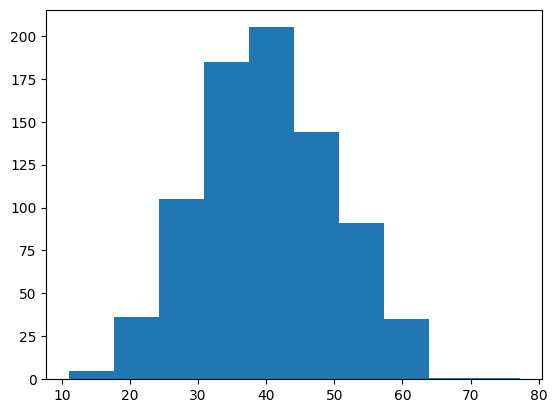

In [6]:
import matplotlib.pyplot as plt
plt.hist(df_train['yield(wt%)'])

# Handling Missing Data

In [5]:
#Using KNN Imputers
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=3)
x_train=df_train.drop(columns=['yield(wt%)'])
y_train=df_train['yield(wt%)']
x_train=pd.DataFrame(imputer.fit_transform(x_train),columns=x_train.columns)
x_test=pd.DataFrame(imputer.fit_transform(df_test),columns=df_test.columns)
#df_test_feature=pd.DataFrame(imputer.fit_transform(df_test_feature),columns=df_test_feature.columns)

In [8]:
print(x_train.isnull().sum())
print()
print(x_test.isnull().sum())

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64


# Outlier Detection

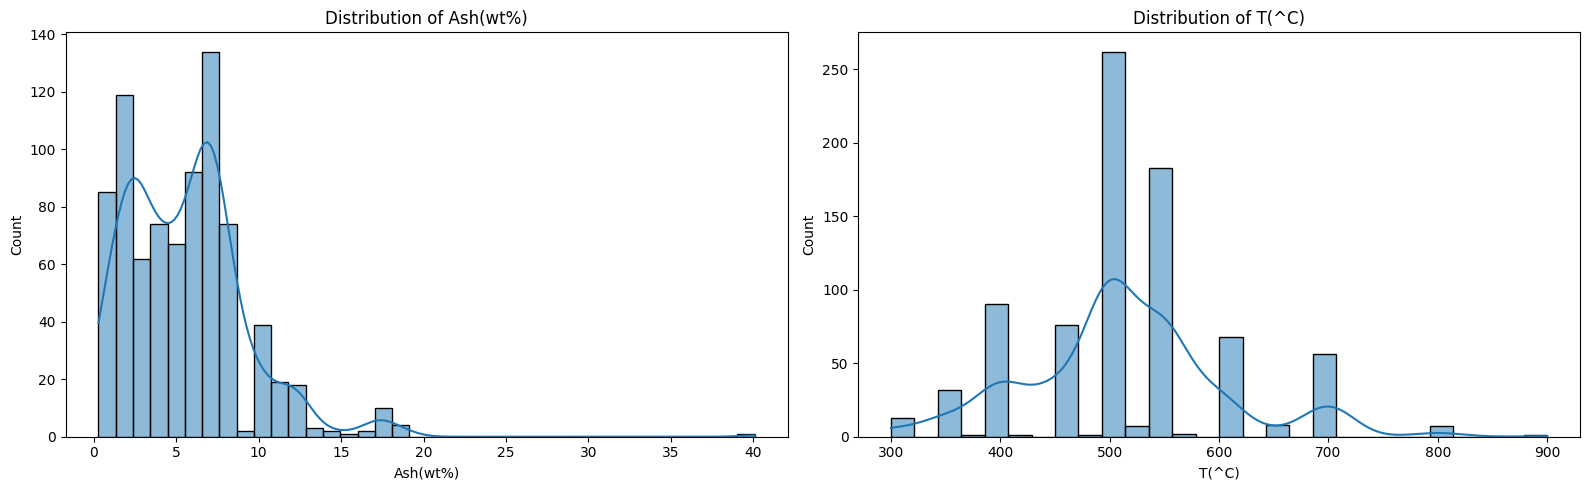

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better visibility
plt.figure(figsize=(16, 5))

# Subplot 1
plt.subplot(1, 2, 1)
sns.histplot(x_train['Ash(wt%)'], kde=True)
plt.title('Distribution of Ash(wt%)')

# Subplot 2
plt.subplot(1, 2, 2)
sns.histplot(x_train['T(^C)'], kde=True)
plt.title('Distribution of T(^C)')

plt.tight_layout()
plt.show()

In [7]:
#Normal distribution, Skewed distribution (for skewed data)
#Zscore , IQR based filtering, percentile, Winsorization

#Right Skewed
print(x_train['Ash(wt%)'].skew())
print(x_train['C(wt%)'].skew())
print(x_train['Cellulose(wt%)'].skew())
print(x_train['FixedCarbon(wt%)'].skew())

1.724731987018256
1.1474474168753819
0.07019267499124901
4.755496298749928


Boxplot of each features

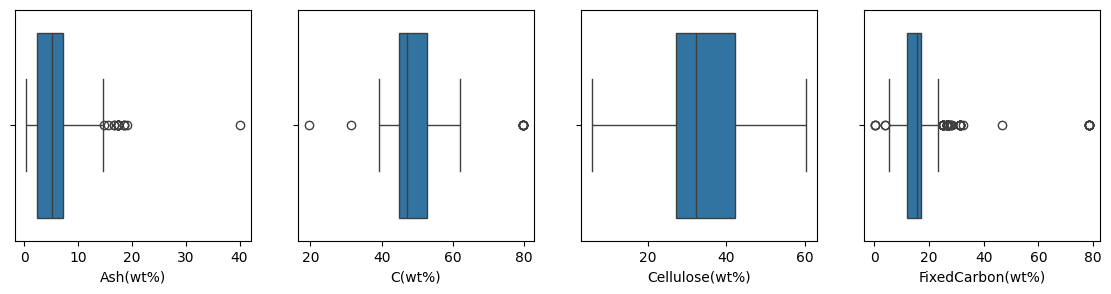

In [11]:
plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train['FixedCarbon(wt%)'])
plt.show()


Finding the IQR for each feature


In [8]:
from numpy import percentile

# Dictionary to store outlier counts
outlier_counts = {}
value_limits={}

for col in x_train.columns:
    q1 = x_train[col].quantile(0.25)
    q3 = x_train[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    value_limits[col]=[lower_limit,upper_limit]

    # Count outliers
    num_outliers = x_train[(x_train[col] < lower_limit) | (x_train[col] > upper_limit)].shape[0]
    outlier_counts[col] = num_outliers

# Convert to Series for better display
outlier_summary = pd.Series(outlier_counts)
print("Total Outliers per Feature:")
print(outlier_summary)
print()
print("Value Limits per Feature:")
print(value_limits)

### Test set ###
outlier_counts_test = {}
value_limits_test={}

for col in x_test.columns:
    q1 = x_test[col].quantile(0.25)
    q3 = x_test[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    value_limits_test[col]=[lower_limit,upper_limit]

    # Count outliers
    num_outliers_test = x_train[(x_train[col] < lower_limit) | (x_train[col] > upper_limit)].shape[0]
    outlier_counts_test[col] = num_outliers_test

print()
outlier_summary = pd.Series(outlier_counts_test)
print("Total Outliers per Feature:")
print(outlier_summary)
print()
print("Value Limits per Feature:")
print(value_limits_test)

Total Outliers per Feature:
Ash(wt%)                      19
FixedCarbon(wt%)              65
Volatiles(wt%)                48
C(wt%)                        11
H(wt%)                       117
O(wt%)                         9
N(wt%)                         0
H/C                          183
Cellulose(wt%)                 0
Hemicellulose(wt%)             1
Lignin(wt%)                    0
T(^C)                          8
HeatingRate(^C/min)          114
ParticleSize(mm)              37
FlowRate-Nitrogen(ml/min)     73
dtype: int64

Value Limits per Feature:
{'Ash(wt%)': [np.float64(-5.097240474454769), np.float64(14.716680394858349)], 'FixedCarbon(wt%)': [np.float64(4.286441244920252), np.float64(24.810685588618245)], 'Volatiles(wt%)': [np.float64(65.64773596082011), np.float64(92.65308473929741)], 'C(wt%)': [np.float64(32.7), np.float64(65.02)], 'H(wt%)': [np.float64(4.621449999999999), np.float64(8.004249999999999)], 'O(wt%)': [np.float64(12.205000000000002), np.float64(69.925)], 'N(w

Capping

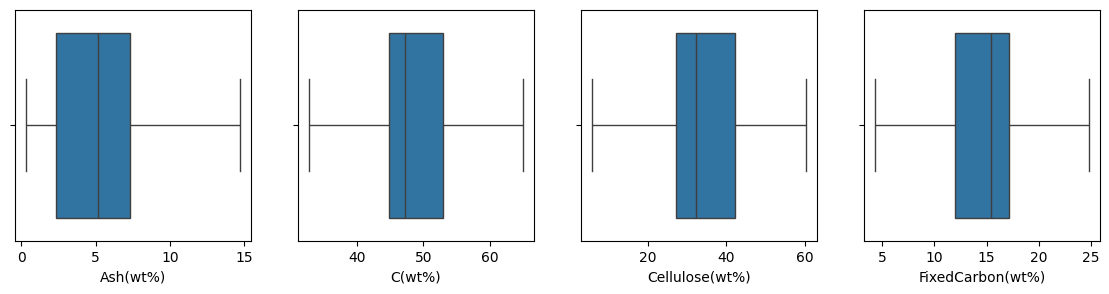

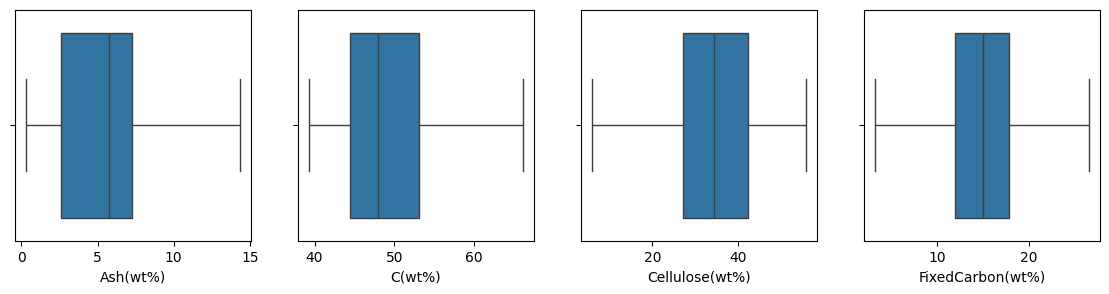

In [9]:
x_train_copy = x_train.copy()

# Apply capping using the limits stored in value_limits
for col in x_train_copy.columns:
    lower, upper = value_limits[col]
    x_train_copy[col] = x_train_copy[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train_copy['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train_copy['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train_copy['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train_copy['FixedCarbon(wt%)'])
plt.show()

x_test_copy = x_test.copy()

# Apply capping using the limits stored in value_limits
for col in x_test_copy.columns:
    lower, upper = value_limits_test[col]
    x_test_copy[col] = x_test_copy[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_test_copy['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_test_copy['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_test_copy['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_test_copy['FixedCarbon(wt%)'])
plt.show()

Investigating Constants

In [10]:
import numpy as np

# Check unique values in capped data
unique_counts = x_train_copy.nunique()
print("Unique values per feature after capping:")
print(unique_counts)

# Identify columns that became constant
constant_cols = unique_counts[unique_counts <= 1].index.tolist()
print(f"\nConstant columns to consider dropping: {constant_cols}")

### Dropping Constant Features Since `H/C` became a constant value after capping, it contains no information for the model. We will drop it from both the training and test sets.
x_train_copy.describe()
# Drop the constant column from training sets
x_train_capped = x_train_copy.drop(columns=['H/C'])
x_test_capped = x_test_copy.drop(columns=['H/C'])

print(f"Remaining features: {list(x_train_capped.columns)}")
print(f"Remaining features: {list(x_test_capped.columns)}")

Unique values per feature after capping:
Ash(wt%)                     135
FixedCarbon(wt%)             132
Volatiles(wt%)               134
C(wt%)                        86
H(wt%)                        74
O(wt%)                        94
N(wt%)                       110
H/C                            1
Cellulose(wt%)               149
Hemicellulose(wt%)           161
Lignin(wt%)                  145
T(^C)                         14
HeatingRate(^C/min)           16
ParticleSize(mm)              52
FlowRate-Nitrogen(ml/min)     11
dtype: int64

Constant columns to consider dropping: ['H/C']
Remaining features: ['Ash(wt%)', 'FixedCarbon(wt%)', 'Volatiles(wt%)', 'C(wt%)', 'H(wt%)', 'O(wt%)', 'N(wt%)', 'Cellulose(wt%)', 'Hemicellulose(wt%)', 'Lignin(wt%)', 'T(^C)', 'HeatingRate(^C/min)', 'ParticleSize(mm)', 'FlowRate-Nitrogen(ml/min)']
Remaining features: ['Ash(wt%)', 'FixedCarbon(wt%)', 'Volatiles(wt%)', 'C(wt%)', 'H(wt%)', 'O(wt%)', 'N(wt%)', 'Cellulose(wt%)', 'Hemicellulose(wt%)', 'Lign

# Feature Scaling
Standard Scaler

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fitting the scaler to the training set to learn the parameter
scaler.fit(x_train_capped)
#Now transform the train set
x_train_scaled=scaler.transform(x_train_capped)

#above step will return numpy array so we need to transform this to DataFrame
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train_capped.columns)
x_train_scaled.describe()


x_test_scaled=scaler.transform(x_test_capped)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test_capped.columns)
x_test_scaled.describe()

#Standardization used for K Means, KNN, ANN, GD and PCA
#algo which uses distance to measure similarity which will affect when the data is having huge range difference, so we need to regularize

,Ash(wt%),FixedCarbon(wt%),Volatiles(wt%),C(wt%),H(wt%),O(wt%),N(wt%),Cellulose(wt%),Hemicellulose(wt%),Lignin(wt%),T(^C),HeatingRate(^C/min),ParticleSize(mm),FlowRate-Nitrogen(ml/min)
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,0.022619,-0.070074,0.071250,0.015887,0.035591,0.024732,-0.033494,0.026130,0.199016,-0.128600,-0.098368,0.101403,-0.085750,0.040678
std,1.027064,1.058332,0.894085,0.975152,0.871119,0.953823,1.005330,0.939782,0.963876,0.825809,0.862884,0.996020,0.930324,0.982371
min,-1.562772,-2.645319,-1.853032,-1.597032,-1.543637,-2.989295,-1.092763,-2.488679,-2.271021,-2.237822,-1.898756,-0.859786,-1.361187,-1.103363
25%,-0.877707,-0.760209,-0.429963,-0.756058,-0.365900,-0.719475,-0.848920,-0.575479,-0.495711,-0.788635,-0.498943,-0.724191,-0.640878,-1.103363
50%,0.069167,-0.095688,-0.005416,-0.177438,-0.132865,0.148836,-0.365105,0.075932,0.077013,0.052492,-0.140017,-0.181811,-0.331371,0.116640
75%,0.524884,0.496532,0.518749,0.663864,0.419257,0.793738,0.409966,0.786590,0.793087,0.340609,0.434265,0.360568,0.484604,0.116640
max,2.628771,2.381642,1.941818,2.793746,1.596994,1.465271,2.298296,1.993815,2.591387,1.524750,1.834078,1.987707,2.172827,1.946645


R Squared Error and Mean Absolute Error

In [27]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
results ={}
def plotresult(y_pred,Method):
  # 1. Extract the ground truth values
  y_actual = df_test_feature['yield']

  # 2. Calculate Evaluation Metrics
  mse = mean_squared_error(y_actual, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_actual, y_pred)
  mae = mean_absolute_error(y_actual, y_pred)

  results[Method] = {
        'MSE': round(mse, 4),
        'RMSE' : round(rmse, 4),
        'R2'  : round(r2, 4),
        'MAE'       : round(mae, 4)
    }

  print(f"Mean Absolute Error (MAE) for {Method}: {mae:.2f}")
  print(f"Root Mean Squared Error (RMSE) for {Method}: {rmse:.2f}")
  print(f"R-squared Score (R2) for {Method}: {r2:.2f}")

  # 3. Create a Comparison DataFrame
  comparison_df = pd.DataFrame({'Actual': y_actual, 'Predicted': y_pred})
  print("\nFirst 5 Comparisons:")
  print(comparison_df.head())

  # 4. Visualization: Actual vs Predicted
  plt.figure(figsize=(8, 6))
  plt.scatter(y_actual, y_pred, alpha=0.5, color='blue')
  plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
  plt.xlabel('Actual Yield')
  plt.ylabel('Predicted Yield')
  plt.title(f'Actual vs Predicted Biofuel Yield ({Method})')
  plt.grid(True)
  plt.show()
  return mse,rmse,r2,mae



# Multiple Linear Regression Model

Mean Absolute Error (MAE) for Multiple Linear Regression: 6.85
Root Mean Squared Error (RMSE) for Multiple Linear Regression: 8.51
R-squared Score (R2) for Multiple Linear Regression: 0.24

First 5 Comparisons:
   Actual  Predicted
0    45.7  38.603487
1    43.8  39.258859
2    43.4  29.971482
3    47.3  39.476914
4    36.6  36.450596


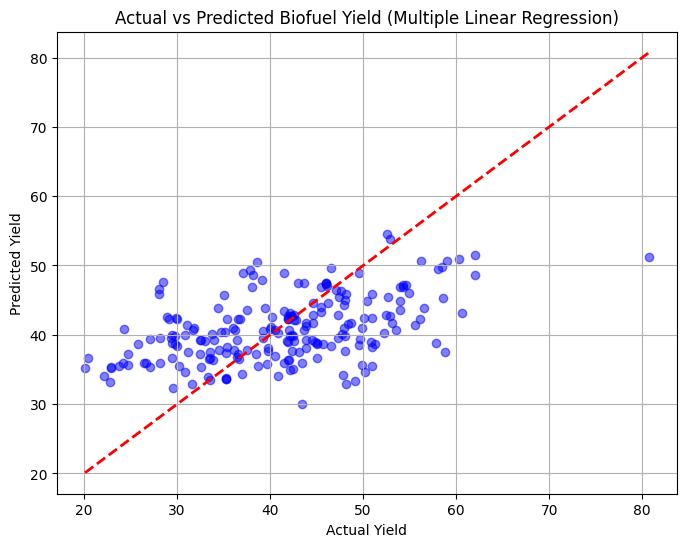

(72.37316185443989,
 np.float64(8.507241730105),
 0.2379812295110203,
 6.8465998795921195)

In [28]:
from sklearn.linear_model import LinearRegression
import numpy as np

reg=LinearRegression()
reg.fit(x_train_scaled,y_train)
y_pred=reg.predict(x_test_scaled)


plotresult(y_pred,'Multiple Linear Regression')


Applying Polynomial regression

Mean Absolute Error (MAE) for Polynomial Regression: 6.67
Root Mean Squared Error (RMSE) for Polynomial Regression: 9.01
R-squared Score (R2) for Polynomial Regression: 0.15

First 5 Comparisons:
   Actual  Predicted
0    45.7  33.250503
1    43.8  41.636842
2    43.4  48.676321
3    47.3  41.860325
4    36.6  41.145291


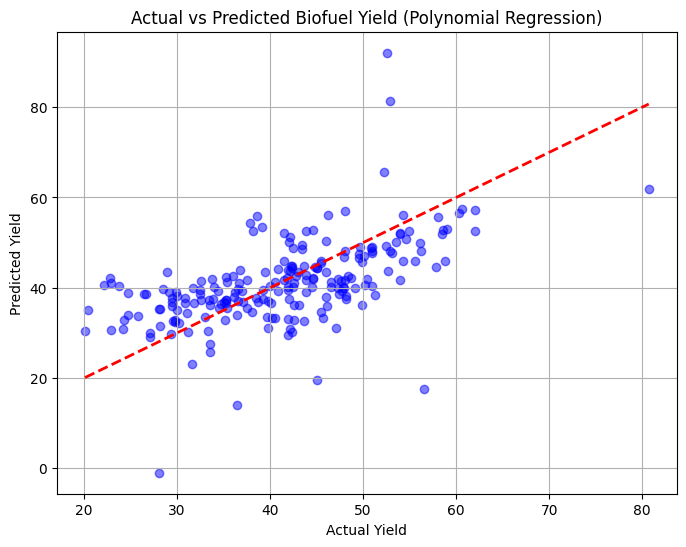

(81.15512251304392,
 np.float64(9.008613795309682),
 0.14551575346879186,
 6.666003581022626)

In [29]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train_scaled)
x_test_poly=poly.fit_transform(x_test_scaled)

reg_poly=LinearRegression()
reg_poly.fit(x_train_poly,y_train)
y_pred_poly=reg_poly.predict(x_test_poly)

plotresult(y_pred_poly,'Polynomial Regression')

Since there are too many variables relative to the number of rows, model memorizes the noise in the training set instead of learning patterns. So, it fails drastically in the test data

In [19]:
#bias - model cannot capture the relationship between the data - high bias
#variance - model is giving different output in different datasets

# overfitting - high variance, low bias
#underfiiting - high bias low variance


#Applying Ridge regression

Mean Absolute Error (MAE) for Ridge Regression: 6.71
Root Mean Squared Error (RMSE) for Ridge Regression: 8.38
R-squared Score (R2) for Ridge Regression: 0.26

First 5 Comparisons:
   Actual  Predicted
0    45.7  37.895837
1    43.8  38.948729
2    43.4  36.401561
3    47.3  40.600992
4    36.6  36.648249


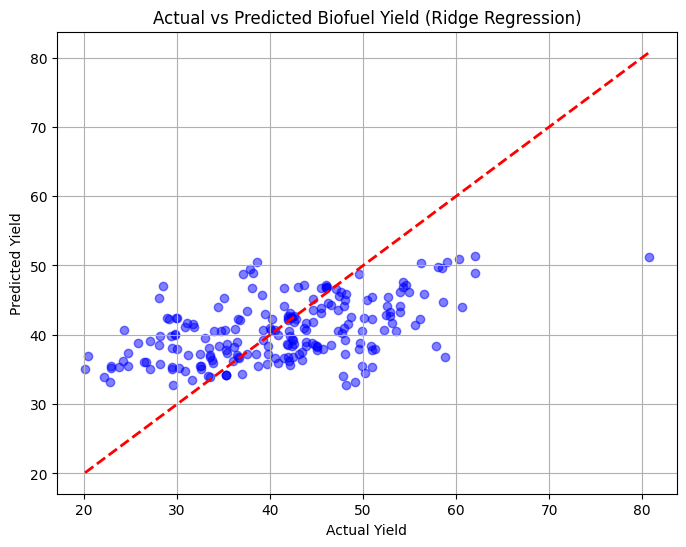

(70.23126657138546,
 np.float64(8.380409689948664),
 0.2605332967178111,
 6.71015283347152)

In [30]:
from sklearn.linear_model import Ridge

R= Ridge(alpha=20,solver='lsqr')
R.fit(x_train_scaled,y_train)
y_pred_r=R.predict(x_test_scaled)

plotresult(y_pred_r,'Ridge Regression')

Mean Absolute Error (MAE) for SGD Regression: 6.72
Root Mean Squared Error (RMSE) for SGD Regression: 8.37
R-squared Score (R2) for SGD Regression: 0.26

First 5 Comparisons:
   Actual  Predicted
0    45.7  38.139660
1    43.8  38.999358
2    43.4  34.827439
3    47.3  40.026798
4    36.6  36.352403


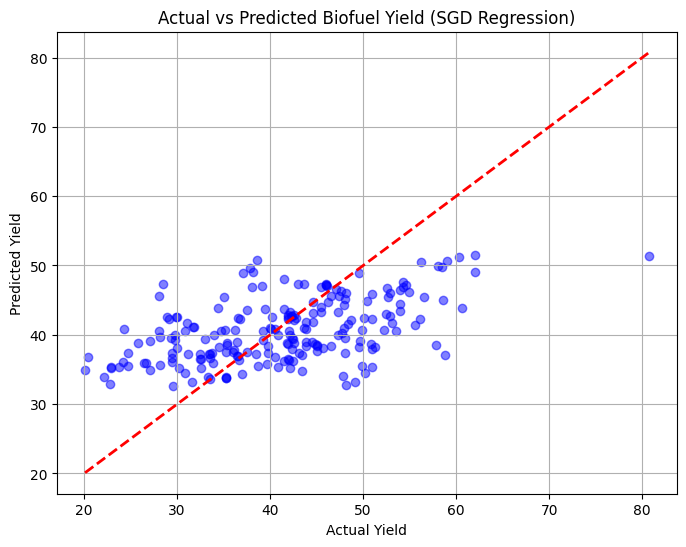

(70.06925334837636,
 np.float64(8.370737921376847),
 0.2622391378588774,
 6.72321273608573)

In [31]:
from sklearn.linear_model import SGDRegressor

R= SGDRegressor(penalty='l2',learning_rate='adaptive',alpha=0.005)
R.fit(x_train_scaled,y_train)
y_pred_sgd=R.predict(x_test_scaled)

plotresult(y_pred_sgd,'SGD Regression')

# Applying KNN

Mean Absolute Error (MAE) for KNN: 4.79
Root Mean Squared Error (RMSE) for KNN: 6.68
R-squared Score (R2) for KNN: 0.53

First 5 Comparisons:
   Actual  Predicted
0    45.7      38.46
1    43.8      37.88
2    43.4      39.54
3    47.3      41.66
4    36.6      32.16


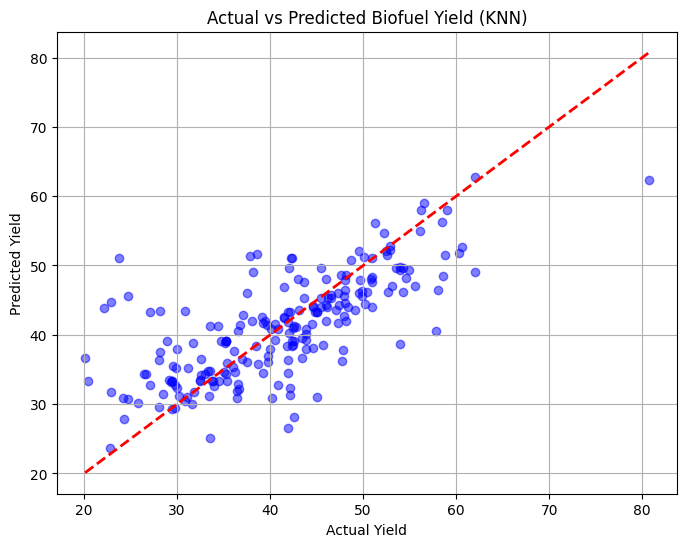

(44.61788113207547,
 np.float64(6.679661752819185),
 0.5302172511065742,
 4.7946226415094335)

In [32]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score

KNN=KNeighborsRegressor(n_neighbors=5)
KNN.fit(x_train_scaled,y_train)
y_pred_knn=KNN.predict(x_test_scaled)



plotresult(y_pred_knn,'KNN')





#Decision Trees

Mean Absolute Error (MAE) for Decision Tree: 5.04
Root Mean Squared Error (RMSE) for Decision Tree: 6.76
R-squared Score (R2) for Decision Tree: 0.52

First 5 Comparisons:
   Actual  Predicted
0    45.7  32.807767
1    43.8  30.709375
2    43.4  48.173684
3    47.3  38.253125
4    36.6  30.709375


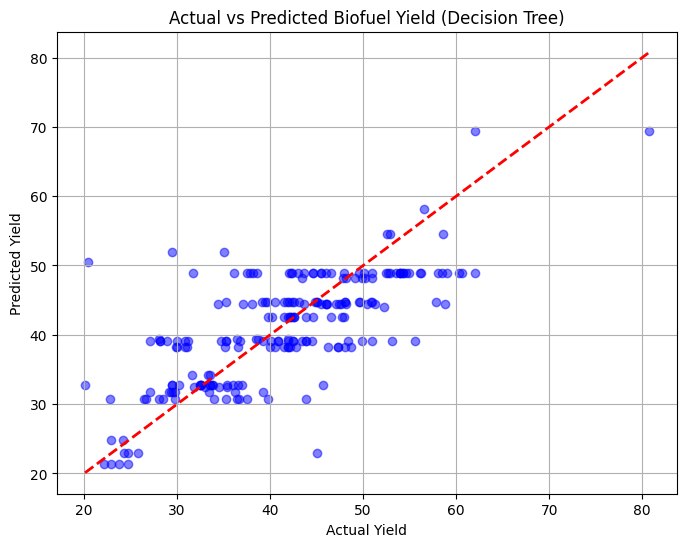

(45.722299036503,
 np.float64(6.761826605030848),
 0.5185888082960954,
 5.039076657890184)

In [33]:
#Max depth =1 leads to underfitting
#Max depth = None leads to overfitting

from sklearn.tree import DecisionTreeRegressor



DT=DecisionTreeRegressor(criterion='friedman_mse',max_depth=5)
DT.fit(x_train_capped,y_train)
y_pred_dt=DT.predict(x_test_capped)

plotresult(y_pred_dt,'Decision Tree')


Hyperparameter Tuning

Best Parameters Found: {'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5}
Mean Absolute Error (MAE) for Tuned Decision Tree: 6.39
Root Mean Squared Error (RMSE) for Tuned Decision Tree: 8.94
R-squared Score (R2) for Tuned Decision Tree: 0.16

First 5 Comparisons:
   Actual  Predicted
0    45.7       32.9
1    43.8       41.9
2    43.4       32.9
3    47.3       41.9
4    36.6       41.9


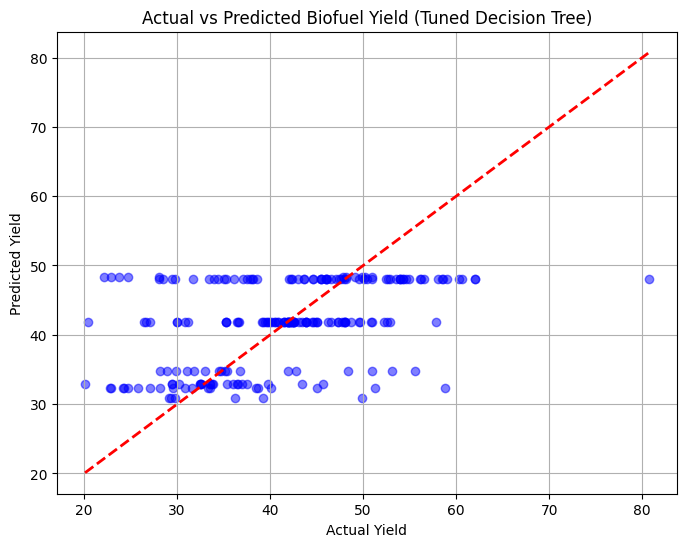

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'ccp_alpha': [0.0, 0.001, 0.01]
}

grid_search = GridSearchCV(estimator=DT, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(x_train_capped, y_train)

print("Best Parameters Found:", grid_search.best_params_)

# Evaluate the best model
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(x_test_capped)
plotresult(y_pred_best, 'Tuned Decision Tree')


#Bagging

Mean Absolute Error (MAE) for Bagging: 2.96
Root Mean Squared Error (RMSE) for Bagging: 4.57
R-squared Score (R2) for Bagging: 0.78

First 5 Comparisons:
   Actual  Predicted
0    45.7  41.840000
1    43.8  41.760000
2    43.4  42.990000
3    47.3  43.683333
4    36.6  35.330000


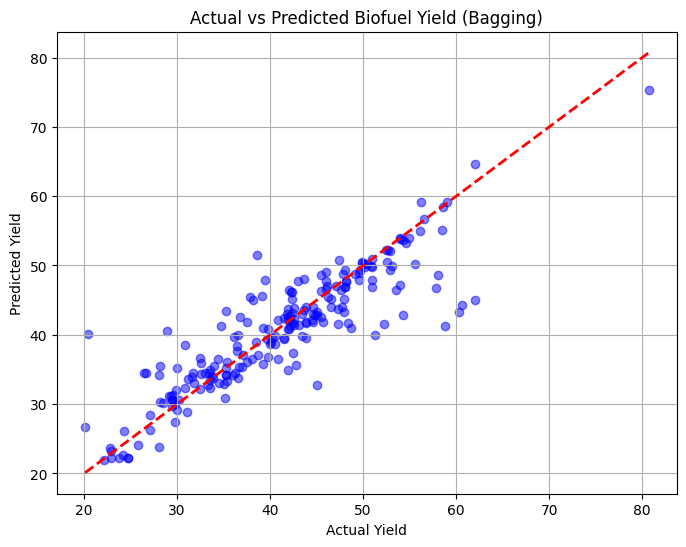

(20.885151661588687,
 np.float64(4.57002753400772),
 0.7800997333424732,
 2.9557519092542686)

In [34]:
#creating a subset of a datasets train with a model, at the  end we will aggregate the results

from sklearn.ensemble import BaggingRegressor

bag_reg=BaggingRegressor(random_state=1)
bag_reg.fit(x_train_capped,y_train)
y_pred_bag=bag_reg.predict(x_test_capped)

plotresult(y_pred_bag,'Bagging')

Hyper Parameter Tuning for Bagging

In [26]:
params={
    'estimator': [DecisionTreeRegressor(), KNeighborsRegressor()],
    'n_estimators': [20,50,100],
    'max_samples': [0.5, 0.8, 1.0],
    'max_features': [0.5, 0.8, 1.0],
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]
}
bagging_regressor_grid = GridSearchCV(BaggingRegressor(random_state=1,n_jobs=1), param_grid=params)
bagging_regressor_grid.fit(x_train_capped, y_train)

print('Train R2 Score : %.3f'%bagging_regressor_grid.score(x_train_capped, y_train))
print('Test R2 Score : %.3f'%bagging_regressor_grid.score(x_test_capped, df_test_feature['yield']))
print("Best Parameters Found:", bagging_regressor_grid.best_params_)
print("Best Score:", bagging_regressor_grid.best_score_)
print("Best Estimator:", bagging_regressor_grid.best_estimator_)

Train R2 Score : 0.645
Test R2 Score : 0.513
Best Parameters Found: {'bootstrap': True, 'bootstrap_features': True, 'estimator': KNeighborsRegressor(), 'max_features': 0.5, 'max_samples': 0.8, 'n_estimators': 50}
Best Score: 0.109130810622653
Best Estimator: BaggingRegressor(bootstrap_features=True, estimator=KNeighborsRegressor(),
                 max_features=0.5, max_samples=0.8, n_estimators=50, n_jobs=1,
                 random_state=1)


#Random Forest

Mean Absolute Error (MAE) for Random Forest: 2.78
Root Mean Squared Error (RMSE) for Random Forest: 4.31
R-squared Score (R2) for Random Forest: 0.80

First 5 Comparisons:
   Actual  Predicted
0    45.7  36.576000
1    43.8  39.636000
2    43.4  43.425000
3    47.3  42.375433
4    36.6  34.974000


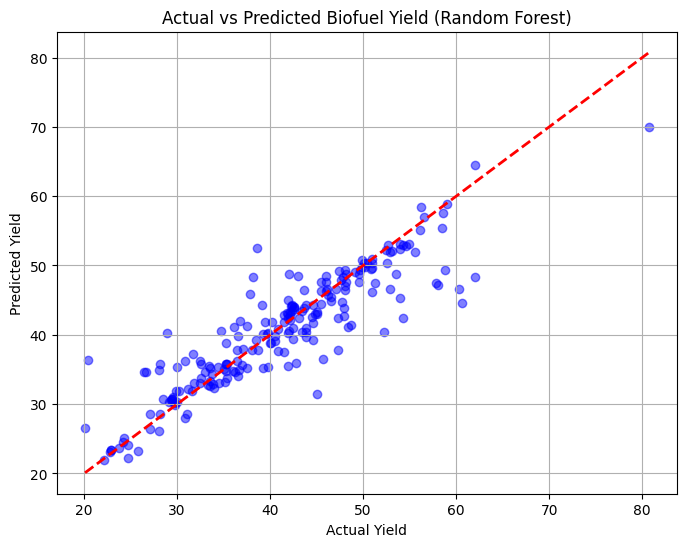

(18.5984208657922,
 np.float64(4.3125886501951705),
 0.804176777163728,
 2.7827988188828985)

In [35]:
#Bagging - col level sampling, Rf node level sampling
from sklearn.ensemble import RandomForestRegressor
ran_reg=RandomForestRegressor(random_state=1)
ran_reg.fit(x_train_capped,y_train)
y_pred_ran=ran_reg.predict(x_test_capped)

plotresult(y_pred_ran,'Random Forest')


Mean Absolute Error (MAE) for XGBoost: 3.05
Root Mean Squared Error (RMSE) for XGBoost: 4.93
R-squared Score (R2) for XGBoost: 0.74

First 5 Comparisons:
   Actual  Predicted
0    45.7  40.780270
1    43.8  41.709114
2    43.4  44.467571
3    47.3  43.564331
4    36.6  34.721844


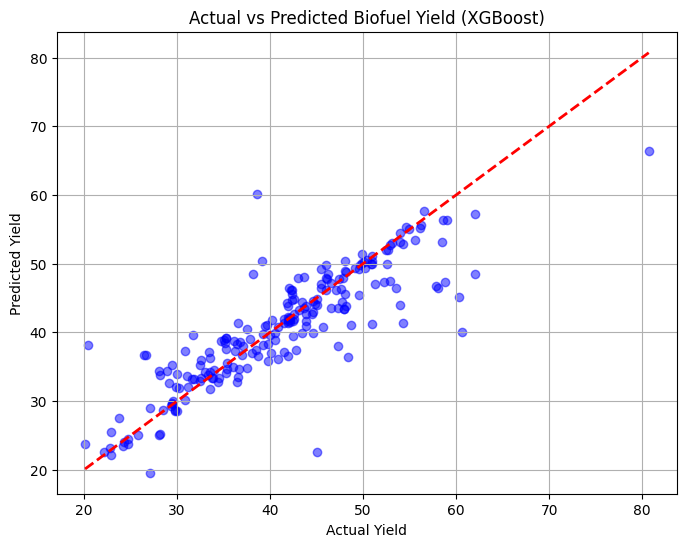

(24.347296664056746,
 np.float64(4.934297991007104),
 0.7436467249283683,
 3.0483262853802375)

In [36]:
import xgboost as xgb

xgb_reg=xgb.XGBRegressor(random_state=1)
xgb_reg.fit(x_train_capped,y_train)
y_pred_xgb=xgb_reg.predict(x_test_capped)

plotresult(y_pred_xgb,'XGBoost')

#Comparison of the results

                                MSE    RMSE      R2     MAE
Random Forest               18.5984  4.3126  0.8042  2.7828
Bagging                     20.8852  4.5700  0.7801  2.9558
XGBoost                     24.3473  4.9343  0.7436  3.0483
KNN                         44.6179  6.6797  0.5302  4.7946
Decision Tree               45.7223  6.7618  0.5186  5.0391
SGD Regression              70.0693  8.3707  0.2622  6.7232
Ridge Regression            70.2313  8.3804  0.2605  6.7102
Multiple Linear Regression  72.3732  8.5072  0.2380  6.8466
Polynomial Regression       81.1551  9.0086  0.1455  6.6660


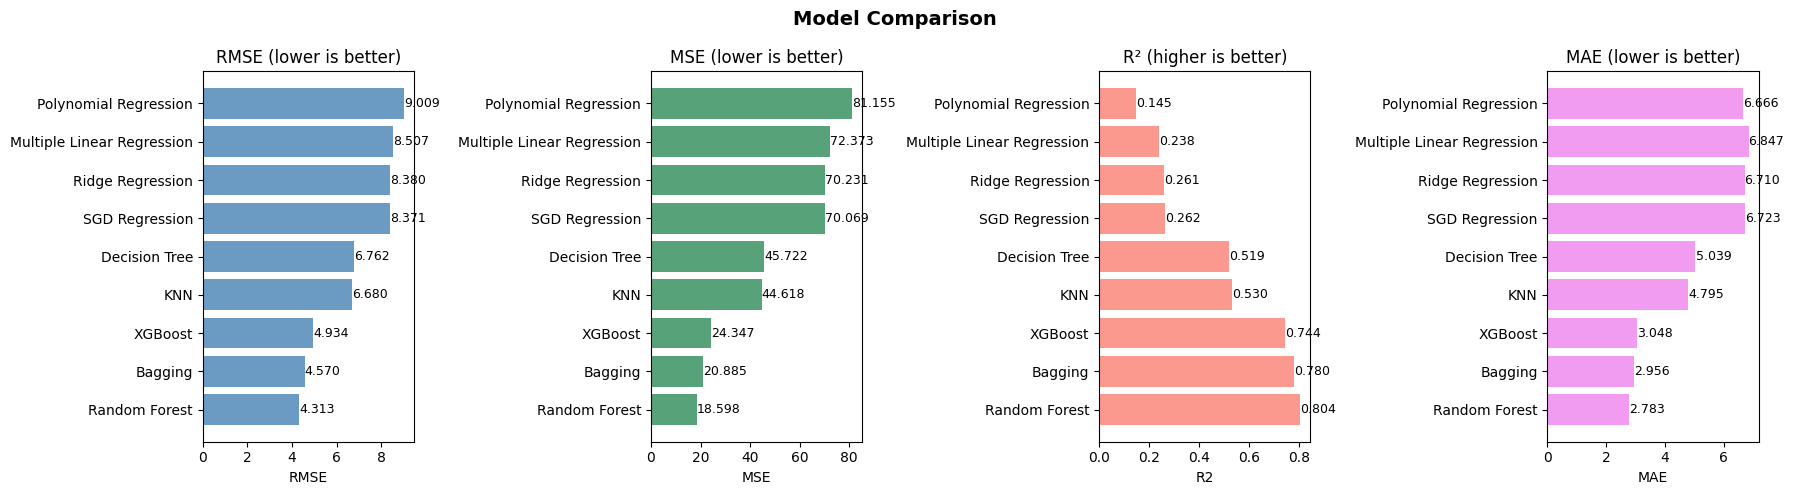

In [43]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)
print(results_df.to_string())

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics = ['RMSE', 'MSE','R2', 'MAE']
colors  = ['steelblue', 'seagreen', 'salmon','violet']
titles  = ['RMSE (lower is better)','MSE (lower is better)', 'R² (higher is better)', 'MAE (lower is better)']

for i, (metric, color, title) in enumerate(zip(metrics, colors, titles)):
    vals = results_df[metric].astype(float)
    axes[i].barh(results_df.index, vals, color=color, alpha=0.8)
    axes[i].set_title(title)
    axes[i].set_xlabel(metric)
    for j, v in enumerate(vals):
        axes[i].text(v + 0.001, j, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()